# Lab: Modulation and Demodulation of Random Signals

## Objective

Study a sampled simulation of a continuous-time random-signal modulation chain based on white Gaussian noise. The lab has two goals:

1. Analyze the standard modulation chain formed by:
   - a baseband low-pass stage with cutoff frequency $f_n$,
   - multiplication by a cosine carrier $\cos(2\pi f_0 t)$ with $f_0 = k f_n$ and $k = 30$,
   - coherent demodulation followed by low-pass filtering.
2. Compare that coherent receiver with a nonlinear envelope detector made of rectification plus RC smoothing.

The key point is that these two receiver structures do not behave the same way for the modulated random process. The coherent receiver is the reference demodulator for the product-modulated signal, while the envelope detector is included as a comparison case to show what changes when a nonlinear demodulator is used.

At each relevant stage, estimate the autocorrelation functions (ACFs) and power spectral densities (PSDs) of the simulated signals.

## Lab Procedure

1. **Parameter selection**
   - Choose $f_n$ (for example, $f_n = 10$ Hz) and compute $(R_0, C_0)$ such that $f_n = 1/(2\pi R_0 C_0)$.
   - Set $f_0 = k f_n$ with $k = 30$ (for example, $f_0 = 300$ Hz when $f_n = 10$ Hz).
   - Choose a sampling frequency $f_s \gg 2 f_0$ and a sufficiently long observation time $T$ to estimate ACFs and PSDs with good resolution.
   - Choose coherent-demodulation filter parameters so the post-multiplier low-pass stage preserves the baseband bandwidth around $f_n$.
   - Choose envelope-detector smoothing parameters so the RC stage suppresses carrier ripple while tracking the baseband envelope, for example with a cutoff frequency $f_{env}$ slightly above $f_n$.

2. **Stage 0: Generation of the input signal**
   - Generate discrete-time white Gaussian noise $x[n]$ with zero mean and unit variance.
   - Estimate $R_{xx}[\ell]$ using sample autocorrelation.
   - Estimate $S_{xx}(f)$ using the FFT of $x[n]$ or a periodogram method.
   - Plot the ACF and PSD of $x[n]$.

3. **Stage 1: Baseband low-pass filtering**
   - Implement the RC low-pass $(R_0, C_0)$ as a digital filter, for example a first-order IIR with cutoff $f_n$, and obtain the band-limited process $x_1[n]$.
   - Estimate $R_{x_1 x_1}[\ell]$ using sample autocorrelation.
   - Estimate $S_{x_1 x_1}(f)$ using a periodogram method.
   - Plot the ACF and PSD of $x_1[n]$.

4. **Stage 2: Cosine modulation**
   - Form the modulated signal $x_2[n] = x_1[n]\cos(2\pi f_0 n T_s)$, with $T_s = 1/f_s$.
   - Estimate $R_{x_2 x_2}[\ell]$ and $S_{x_2 x_2}(f)$.
   - Observe that the ACF of $x_2[n]$ exhibits an oscillatory factor at $f_0$ and that the PSD shows translated sidebands centered at $\pm f_0$.

5. **Stage 3A: Coherent demodulation reference path**
   - Multiply the modulated signal again by the synchronized carrier to form $x_{c}[n] = x_2[n]\cos(2\pi f_0 n T_s)$.
   - Apply a low-pass filter to obtain the coherent-receiver output $x_{coh}[n]$.
   - Estimate $R_{x_{coh} x_{coh}}[\ell]$ and $S_{x_{coh} x_{coh}}(f)$.
   - Compare $x_{coh}[n]$ with $x_1[n]$ and identify the expected scale factor introduced by modulation and demodulation.

6. **Stage 3B: Envelope-detector comparison path**
   - Rectify the modulated signal $x_2[n]$.
   - Apply an RC smoothing filter to obtain the envelope-detector output $x_{env}[n]$.
   - Estimate $R_{x_{env} x_{env}}[\ell]$ and $S_{x_{env} x_{env}}(f)$.
   - Compare $x_{env}[n]$ with $x_1[n]$ and describe which features are preserved and which are lost due to nonlinear detection.

7. **Comparison and discussion**
   - Plot on common axes representative ACFs such as $R_{x_1 x_1}(\tau)$, $R_{x_2 x_2}(\tau)$, $R_{x_{coh} x_{coh}}(\tau)$, and $R_{x_{env} x_{env}}(\tau)$.
   - Plot on common axes the corresponding PSDs $S_{x_1 x_1}(f)$, $S_{x_2 x_2}(f)$, $S_{x_{coh} x_{coh}}(f)$, and $S_{x_{env} x_{env}}(f)$.
   - Explain why coherent demodulation is the appropriate recovery method for the product-modulated signal.
   - Explain why the envelope detector does not reproduce the original baseband process exactly, even when its output still reflects the slow envelope variation.
   - Relate the observed changes in ACF and PSD to the theoretical effects of linear filtering, modulation, synchronous detection, and nonlinear rectification.

## Simulation Model

Use the following discrete-time model throughout the lab.

Let $T_s = 1/f_s$ and define the one-pole RC coefficient

$$
\alpha(f_c) = e^{-2\pi f_c T_s}.
$$

For any RC low-pass stage with cutoff frequency $f_c$, implement the recursion

$$
y[n] = (1-\alpha(f_c))\,x[n] + \alpha(f_c)\,y[n-1],
$$

with initial condition $y[0] = (1-\alpha(f_c))x[0]$.

Using that convention, the complete simulation chain is:

1. **White-noise source**
   - Generate $x[n] \sim \mathcal{N}(0,1)$ independently.

2. **Baseband low-pass stage**
   - Use cutoff $f_n$.
   - Compute
$$
x_1[n] = (1-\alpha_n)x[n] + \alpha_n x_1[n-1], \qquad \alpha_n = \alpha(f_n).
$$

3. **Carrier modulation**
   - Define the carrier
$$
c[n] = \cos(2\pi f_0 n T_s).
$$
   - Form
$$
x_2[n] = x_1[n]c[n].
$$

4. **Coherent receiver branch**
   - Multiply again by the synchronized carrier:
$$
x_c[n] = x_2[n]c[n].
$$
   - Apply the same low-pass structure with cutoff $f_n$:
$$
x_{coh}[n] = (1-\alpha_n)x_c[n] + \alpha_n x_{coh}[n-1].
$$

5. **Envelope-detector branch**
   - Use **full-wave rectification**:
$$
x_r[n] = |x_2[n]|.
$$
   - Smooth with another RC low-pass stage with cutoff $f_{env}$:
$$
x_{env}[n] = (1-\alpha_{env})x_r[n] + \alpha_{env}x_{env}[n-1], \qquad \alpha_{env} = \alpha(f_{env}).
$$

This notebook therefore studies one linear reference receiver and one nonlinear comparison receiver under the same input and carrier conditions.

## Default Parameters

Use these defaults unless the instructor specifies alternatives:

- Baseband cutoff: $f_n = 10$ Hz.
- Carrier ratio: $k = 30$.
- Carrier frequency: $f_0 = k f_n = 300$ Hz.
- Sampling frequency: $f_s = 5000$ Hz.
- Observation time: $T = 20$ s.
- Number of samples: $N = T f_s = 100000$.
- Envelope-detector smoothing cutoff: $f_{env} = 15$ Hz.
- Random seed: use a fixed seed such as `12345` for reproducible plots.

These values ensure that:

- the carrier is well above the baseband bandwidth,
- the sampling rate comfortably exceeds $2f_0$,
- the record length is long enough to estimate smooth ACFs and PSDs,
- the envelope smoother tracks slow baseband variation while attenuating carrier ripple.

## Estimation Conventions

Use one consistent set of estimators across all stages.

1. **Sample ACF**
   - Remove the sample mean before estimating the ACF unless you are explicitly studying the detector DC term.
   - Use the unbiased estimator
$$
\hat R_{xx}[\ell] = \frac{1}{N}\sum_{n=0}^{N-1-|\ell|} \tilde x[n]\tilde x[n+|\ell|],
$$
   where $\tilde x[n] = x[n] - \bar x$.
   - Plot lags over a symmetric window such as $|\ell| \leq 2000$.

2. **PSD estimate**
   - Use a periodogram or Welch estimate, but keep the same method for every signal.
   - Prefer a two-sided PSD centered at zero frequency using FFT shifting, since modulation creates components at both positive and negative frequencies.
   - State clearly in the notebook which estimator you used.

3. **Amplitude comparisons**
   - When comparing $x_{coh}[n]$ with $x_1[n]$, use a best-fit scale factor rather than assuming exact sample-by-sample equality.
   - In the non-ideal RC model used here, the coherent branch can introduce additional attenuation beyond the ideal $1/2$ factor.
   - When comparing $x_{env}[n]$ with $x_1[n]$, compare shape and second-order behavior, not sign-by-sign waveform equality.
   - For the envelope branch, compare $x_{env}[n]$ with a scaled magnitude reference such as $|x_1[n]|$.

## Expected Results

Your simulations should support the following conclusions.

1. **Input white noise $x[n]$**
   - The ACF is strongly concentrated near zero lag.
   - The PSD is approximately flat over the discrete-time frequency range, up to finite-record variation.

2. **Baseband process $x_1[n]$**
   - The ACF becomes wider and smoother than that of white noise.
   - The PSD becomes low-pass and concentrated near zero frequency.

3. **Modulated process $x_2[n]$**
   - The ACF acquires an oscillatory factor at the carrier frequency.
   - The PSD shifts from baseband to two sidebands centered near $\pm f_0$.

4. **Coherent receiver output $x_{coh}[n]$**
   - After low-pass filtering, the signal returns to baseband.
   - Its waveform should match a scaled version of $x_1[n]$ only approximately, because the receiver uses a non-ideal RC low-pass filter.
   - Its ACF and PSD should return to baseband and remain closer to those of $x_1[n]$ than the envelope-detector output does.
   - For ideal synchronous demodulation, the main expected scale is approximately $1/2$ in amplitude after the second multiplication and low-pass recovery, but the exact discrete-time RC model used here can attenuate the signal further.

5. **Envelope-detector output $x_{env}[n]$**
   - The output follows slow envelope variation and is better compared with a scaled version of $|x_1[n]|$ than with $x_1[n]$ itself.
   - It generally has a positive mean due to rectification.
   - Its ACF and PSD differ from those of $x_1[n]$ because rectification is nonlinear.
   - It should not be interpreted as exact recovery of the original product-modulated baseband process.

## Deliverables

A complete lab submission should include the following.

1. **Parameter table**
   - Report the values of $f_n$, $f_0$, $f_s$, $T$, $N$, $f_{env}$, and the random seed.

2. **Implementation summary**
   - State the exact recursion used for the RC filters.
   - State whether the PSD was computed with a periodogram or Welch estimate.
   - State whether the ACF was mean-removed and biased or unbiased.

3. **Required plots**
   - Time realizations of $x[n]$, $x_1[n]$, $x_2[n]$, $x_{coh}[n]$, and $x_{env}[n]$ over a short interval.
   - ACF plots for $x[n]$, $x_1[n]$, $x_2[n]$, $x_{coh}[n]$, and $x_{env}[n]$.
   - PSD plots for the same signals on consistent axes.
   - At least one direct comparison plot of $x_1[n]$ and the appropriately scaled $x_{coh}[n]$.

4. **Discussion questions**
   - Why does modulation shift the PSD away from zero frequency?
   - Why does coherent demodulation recover the baseband shape up to a scale factor?
   - Why does envelope detection fail to reproduce the signed baseband process exactly?
   - How do the observed ACFs support the theoretical interpretation of each stage?

5. **Short conclusion**
   - Summarize which receiver preserves the original second-order structure more faithfully.
   - State whether the envelope detector is appropriate for this product-modulated random signal and justify the answer from the plots and statistics.


seed = 12345
f_n = 10.0 Hz
k = 30
f_0 = 300.0 Hz
f_s = 5000.0 Hz
T = 20.0 s
N = 100000
f_env = 15.0 Hz


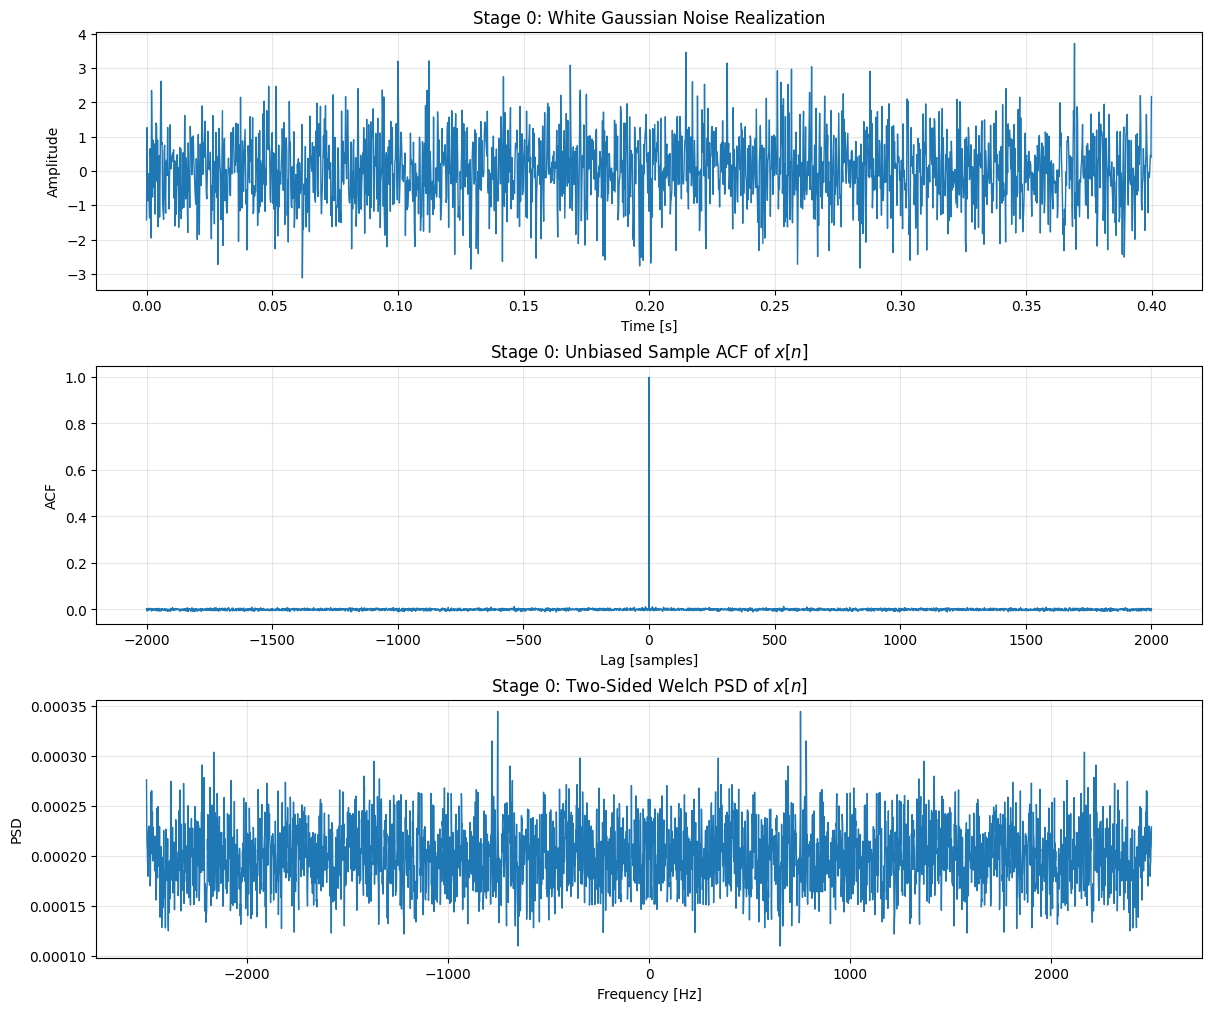

Sample mean of x[n]: +5.7297e-03
Sample variance of x[n]: 0.9980


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


def unbiased_acf(x: np.ndarray, max_lag: int) -> tuple[np.ndarray, np.ndarray]:
    """Returns the mean-removed unbiased sample ACF over symmetric lags."""
    x_centered = np.asarray(x, dtype=float) - np.mean(x)
    n = x_centered.size
    corr_full = np.correlate(x_centered, x_centered, mode="full")
    center = n - 1
    lags = np.arange(-max_lag, max_lag + 1)
    acf = corr_full[center - max_lag : center + max_lag + 1]
    normalization = n - np.abs(lags)
    acf = acf / normalization
    return lags, acf


def welch_psd(x: np.ndarray, fs: float) -> tuple[np.ndarray, np.ndarray]:
    """Returns a two-sided Welch PSD centered at zero frequency."""
    x_centered = np.asarray(x, dtype=float) - np.mean(x)
    nperseg = min(4096, x_centered.size)
    freqs, psd = signal.welch(
        x_centered,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2,
        detrend=False,
        return_onesided=False,
        scaling="density",
    )
    return np.fft.fftshift(freqs), np.fft.fftshift(psd)


# Parameter selection
seed = 12345
rng = np.random.default_rng(seed)

f_n = 10.0
k = 30
f_0 = k * f_n
f_s = 5000.0
T = 20.0
N = int(T * f_s)
f_env = 15.0
T_s = 1.0 / f_s
t = np.arange(N) * T_s

print(f"seed = {seed}")
print(f"f_n = {f_n:.1f} Hz")
print(f"k = {k}")
print(f"f_0 = {f_0:.1f} Hz")
print(f"f_s = {f_s:.1f} Hz")
print(f"T = {T:.1f} s")
print(f"N = {N}")
print(f"f_env = {f_env:.1f} Hz")


# Stage 0: white Gaussian input signal
x = rng.normal(loc=0.0, scale=1.0, size=N)

max_lag = 2000
lags, acf_x = unbiased_acf(x, max_lag=max_lag)
freqs_x, psd_x = welch_psd(x, fs=f_s)

time_window = 2000
fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

axes[0].plot(t[:time_window], x[:time_window], linewidth=1.0)
axes[0].set_title("Stage 0: White Gaussian Noise Realization")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(lags, acf_x, linewidth=1.0)
axes[1].set_title("Stage 0: Unbiased Sample ACF of $x[n]$")
axes[1].set_xlabel("Lag [samples]")
axes[1].set_ylabel("ACF")
axes[1].grid(True, alpha=0.3)

axes[2].plot(freqs_x, psd_x, linewidth=1.0)
axes[2].set_title("Stage 0: Two-Sided Welch PSD of $x[n]$")
axes[2].set_xlabel("Frequency [Hz]")
axes[2].set_ylabel("PSD")
axes[2].grid(True, alpha=0.3)

plt.show()

print(f"Sample mean of x[n]: {np.mean(x):+.4e}")
print(f"Sample variance of x[n]: {np.var(x):.4f}")


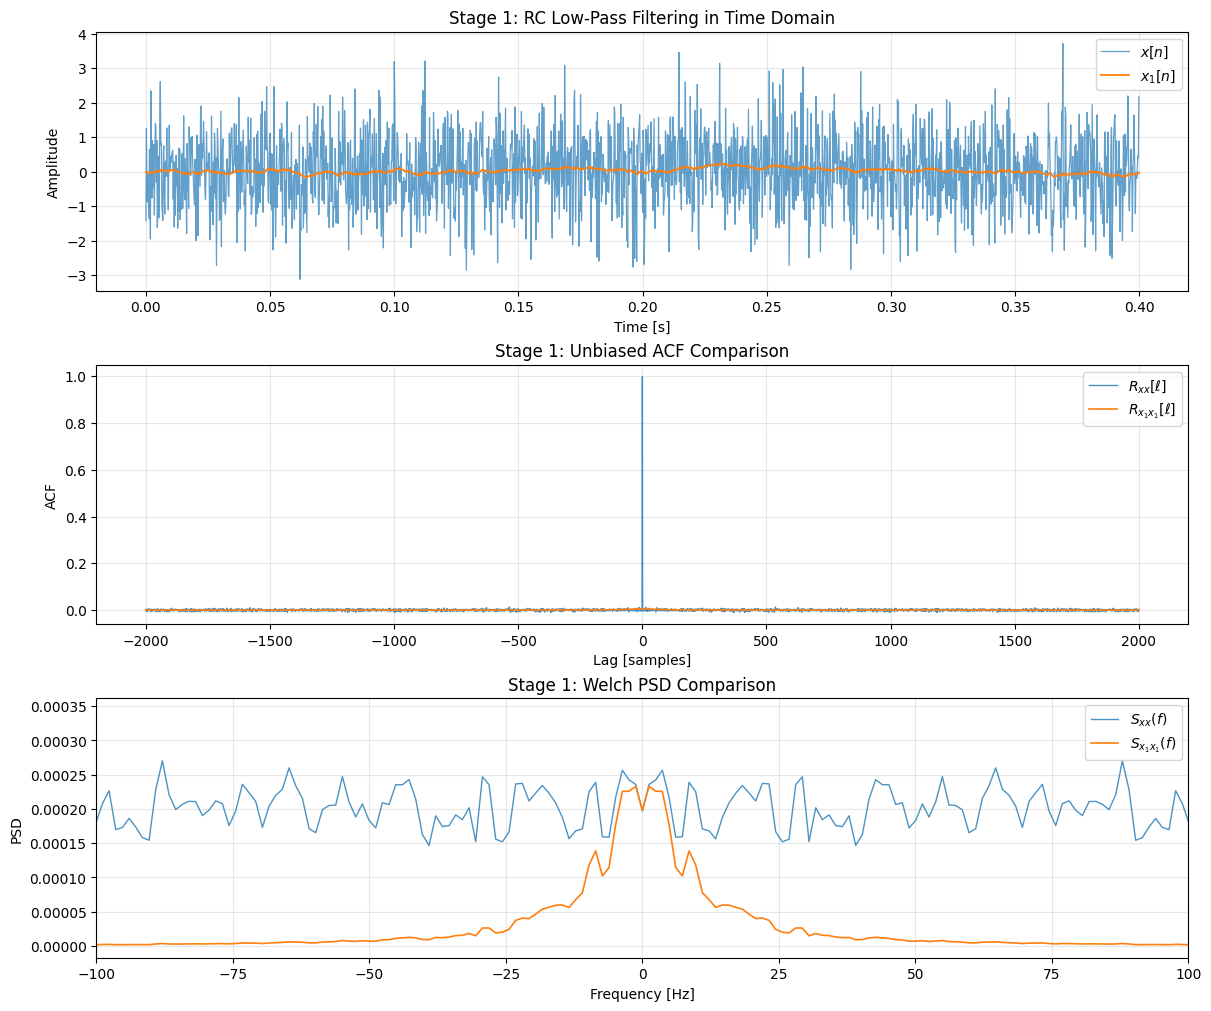

Stage 1 RC coefficient alpha_n = 0.987512
Sample mean of x_1[n]: +5.7262e-03
Sample variance of x_1[n]: 0.0065


In [23]:
def alpha_from_cutoff(f_c: float, fs: float) -> float:
    """Returns the one-pole RC coefficient for the chosen cutoff."""
    return float(np.exp(-2.0 * np.pi * f_c / fs))


def rc_lowpass(x: np.ndarray, f_c: float, fs: float) -> tuple[np.ndarray, float]:
    """Applies the notebook's first-order RC low-pass recursion."""
    alpha = alpha_from_cutoff(f_c, fs)
    x = np.asarray(x, dtype=float)
    y = np.empty_like(x)
    y[0] = (1.0 - alpha) * x[0]
    for n in range(1, x.size):
        y[n] = (1.0 - alpha) * x[n] + alpha * y[n - 1]
    return y, alpha


# Stage 1: baseband low-pass filtering
x_1, alpha_n = rc_lowpass(x, f_c=f_n, fs=f_s)

lags_1, acf_x1 = unbiased_acf(x_1, max_lag=max_lag)
freqs_x1, psd_x1 = welch_psd(x_1, fs=f_s)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

axes[0].plot(t[:time_window], x[:time_window], label=r"$x[n]$", linewidth=0.9, alpha=0.7)
axes[0].plot(t[:time_window], x_1[:time_window], label=r"$x_1[n]$", linewidth=1.3)
axes[0].set_title("Stage 1: RC Low-Pass Filtering in Time Domain")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lags, acf_x, label=r"$R_{xx}[\ell]$", linewidth=1.0, alpha=0.8)
axes[1].plot(lags_1, acf_x1, label=r"$R_{x_1x_1}[\ell]$", linewidth=1.2)
axes[1].set_title("Stage 1: Unbiased ACF Comparison")
axes[1].set_xlabel("Lag [samples]")
axes[1].set_ylabel("ACF")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(freqs_x, psd_x, label=r"$S_{xx}(f)$", linewidth=1.0, alpha=0.8)
axes[2].plot(freqs_x1, psd_x1, label=r"$S_{x_1x_1}(f)$", linewidth=1.2)
axes[2].set_title("Stage 1: Welch PSD Comparison")
axes[2].set_xlabel("Frequency [Hz]")
axes[2].set_ylabel("PSD")
axes[2].set_xlim(-100, 100)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.show()

print(f"Stage 1 RC coefficient alpha_n = {alpha_n:.6f}")
print(f"Sample mean of x_1[n]: {np.mean(x_1):+.4e}")
print(f"Sample variance of x_1[n]: {np.var(x_1):.4f}")


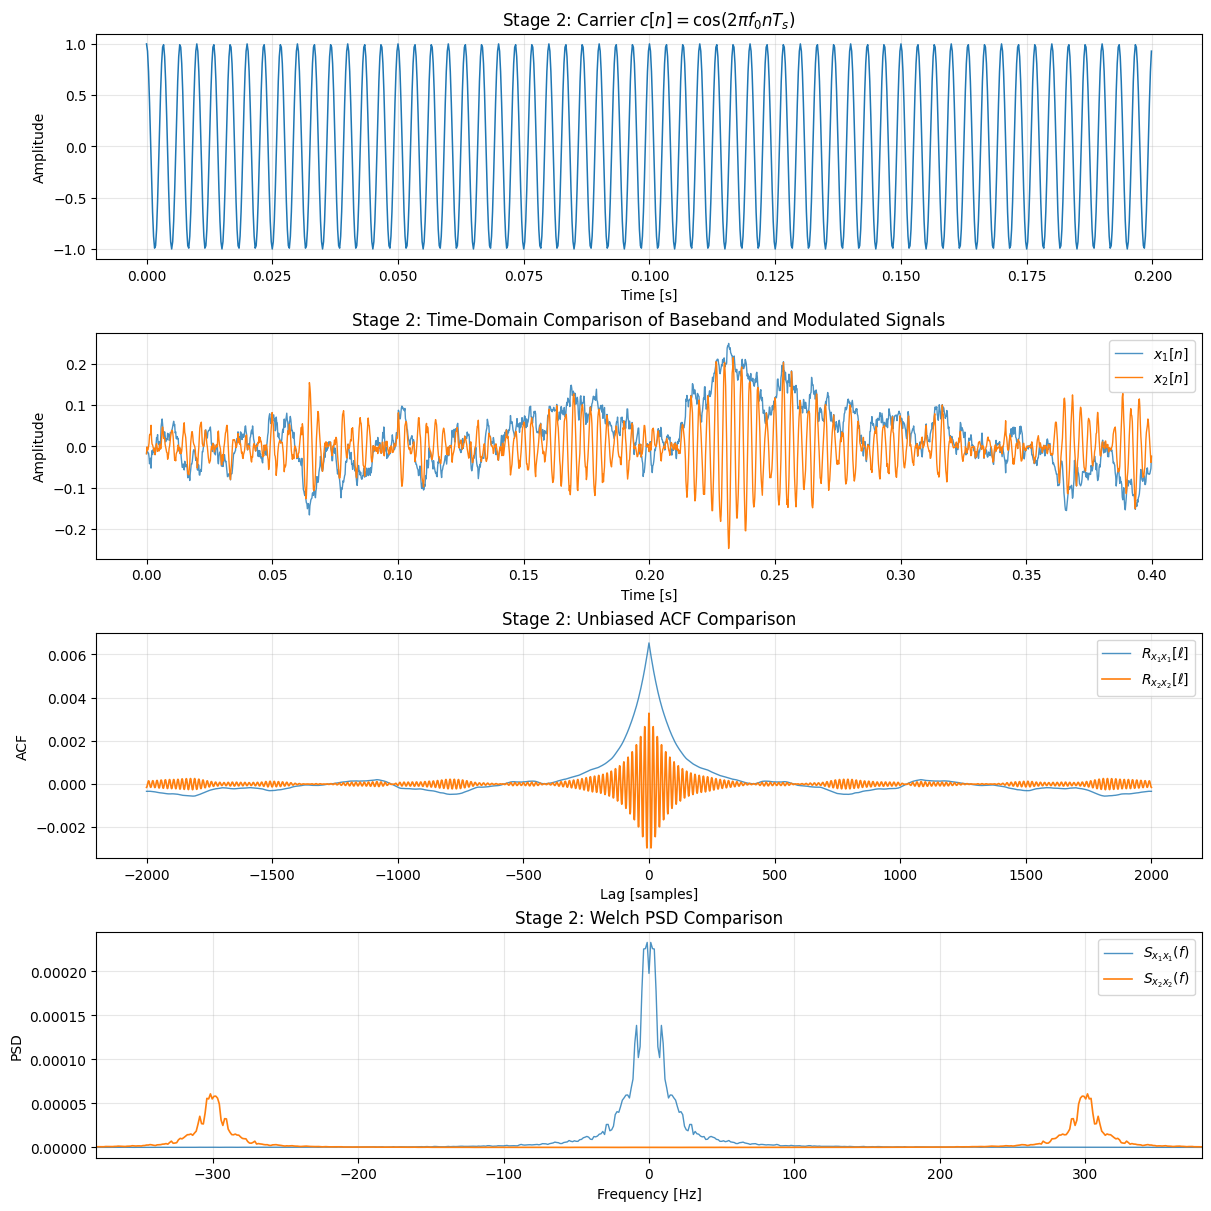

Carrier frequency f_0 = 300.0 Hz
Sample mean of x_2[n]: -1.1170e-04
Sample variance of x_2[n]: 0.0033


In [24]:
# Stage 2: cosine modulation
carrier = np.cos(2.0 * np.pi * f_0 * t)
x_2 = x_1 * carrier

lags_2, acf_x2 = unbiased_acf(x_2, max_lag=max_lag)
freqs_x2, psd_x2 = welch_psd(x_2, fs=f_s)

fig, axes = plt.subplots(4, 1, figsize=(12, 12), constrained_layout=True)

carrier_window = 1000
axes[0].plot(t[:carrier_window], carrier[:carrier_window], linewidth=1.1)
axes[0].set_title("Stage 2: Carrier $c[n] = \\cos(2\\pi f_0 n T_s)$")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[:time_window], x_1[:time_window], label=r"$x_1[n]$", linewidth=1.0, alpha=0.8)
axes[1].plot(t[:time_window], x_2[:time_window], label=r"$x_2[n]$", linewidth=1.0)
axes[1].set_title("Stage 2: Time-Domain Comparison of Baseband and Modulated Signals")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Amplitude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(lags_1, acf_x1, label=r"$R_{x_1x_1}[\ell]$", linewidth=1.0, alpha=0.8)
axes[2].plot(lags_2, acf_x2, label=r"$R_{x_2x_2}[\ell]$", linewidth=1.2)
axes[2].set_title("Stage 2: Unbiased ACF Comparison")
axes[2].set_xlabel("Lag [samples]")
axes[2].set_ylabel("ACF")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(freqs_x1, psd_x1, label=r"$S_{x_1x_1}(f)$", linewidth=1.0, alpha=0.8)
axes[3].plot(freqs_x2, psd_x2, label=r"$S_{x_2x_2}(f)$", linewidth=1.2)
axes[3].set_title("Stage 2: Welch PSD Comparison")
axes[3].set_xlabel("Frequency [Hz]")
axes[3].set_ylabel("PSD")
axes[3].set_xlim(-(f_0 + 80.0), f_0 + 80.0)
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.show()

print(f"Carrier frequency f_0 = {f_0:.1f} Hz")
print(f"Sample mean of x_2[n]: {np.mean(x_2):+.4e}")
print(f"Sample variance of x_2[n]: {np.var(x_2):.4f}")


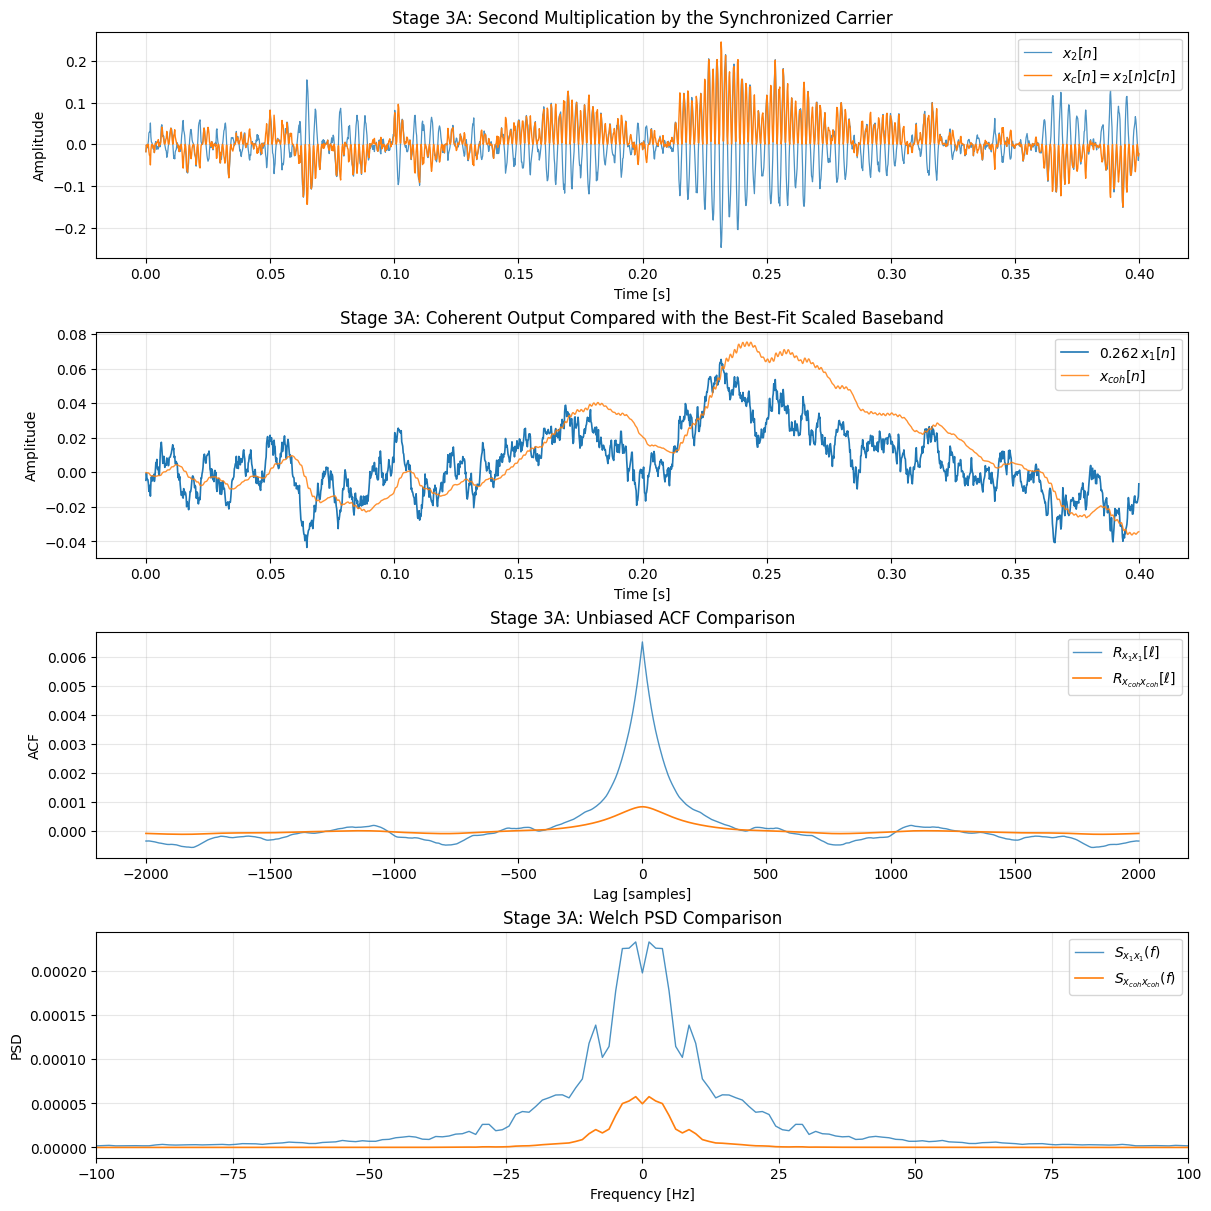

Coherent low-pass RC coefficient alpha_coh = 0.987512
Ideal coherent amplitude scale (ideal mixer): 0.50
Best-fit coherent amplitude scale          : 0.2620
RMSE between x_coh[n] and best-fit*x_1[n] : 2.0105e-02
Sample mean of x_coh[n]: +2.8012e-03
Sample variance of x_coh[n]: 0.0008


In [25]:
# Stage 3A: coherent demodulation reference path
x_c = x_2 * carrier
x_coh, alpha_coh = rc_lowpass(x_c, f_c=f_n, fs=f_s)

lags_coh, acf_xcoh = unbiased_acf(x_coh, max_lag=max_lag)
freqs_xcoh, psd_xcoh = welch_psd(x_coh, fs=f_s)

ideal_scale = 0.5
coh_fit_scale = np.dot(x_coh, x_1) / np.dot(x_1, x_1)
scaled_reference = coh_fit_scale * x_1
coh_error = x_coh - scaled_reference
rmse_coh = np.sqrt(np.mean(coh_error**2))

fig, axes = plt.subplots(4, 1, figsize=(12, 12), constrained_layout=True)

axes[0].plot(t[:time_window], x_2[:time_window], label=r"$x_2[n]$", linewidth=0.9, alpha=0.8)
axes[0].plot(t[:time_window], x_c[:time_window], label=r"$x_c[n] = x_2[n]c[n]$", linewidth=1.0)
axes[0].set_title("Stage 3A: Second Multiplication by the Synchronized Carrier")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[:time_window], scaled_reference[:time_window], label=fr"${coh_fit_scale:.3f}\,x_1[n]$", linewidth=1.2)
axes[1].plot(t[:time_window], x_coh[:time_window], label=r"$x_{coh}[n]$", linewidth=1.0, alpha=0.85)
axes[1].set_title("Stage 3A: Coherent Output Compared with the Best-Fit Scaled Baseband")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Amplitude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(lags_1, acf_x1, label=r"$R_{x_1x_1}[\ell]$", linewidth=1.0, alpha=0.8)
axes[2].plot(lags_coh, acf_xcoh, label=r"$R_{x_{coh}x_{coh}}[\ell]$", linewidth=1.2)
axes[2].set_title("Stage 3A: Unbiased ACF Comparison")
axes[2].set_xlabel("Lag [samples]")
axes[2].set_ylabel("ACF")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(freqs_x1, psd_x1, label=r"$S_{x_1x_1}(f)$", linewidth=1.0, alpha=0.8)
axes[3].plot(freqs_xcoh, psd_xcoh, label=r"$S_{x_{coh}x_{coh}}(f)$", linewidth=1.2)
axes[3].set_title("Stage 3A: Welch PSD Comparison")
axes[3].set_xlabel("Frequency [Hz]")
axes[3].set_ylabel("PSD")
axes[3].set_xlim(-100, 100)
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.show()

print(f"Coherent low-pass RC coefficient alpha_coh = {alpha_coh:.6f}")
print(f"Ideal coherent amplitude scale (ideal mixer): {ideal_scale:.2f}")
print(f"Best-fit coherent amplitude scale          : {coh_fit_scale:.4f}")
print(f"RMSE between x_coh[n] and best-fit*x_1[n] : {rmse_coh:.4e}")
print(f"Sample mean of x_coh[n]: {np.mean(x_coh):+.4e}")
print(f"Sample variance of x_coh[n]: {np.var(x_coh):.4f}")


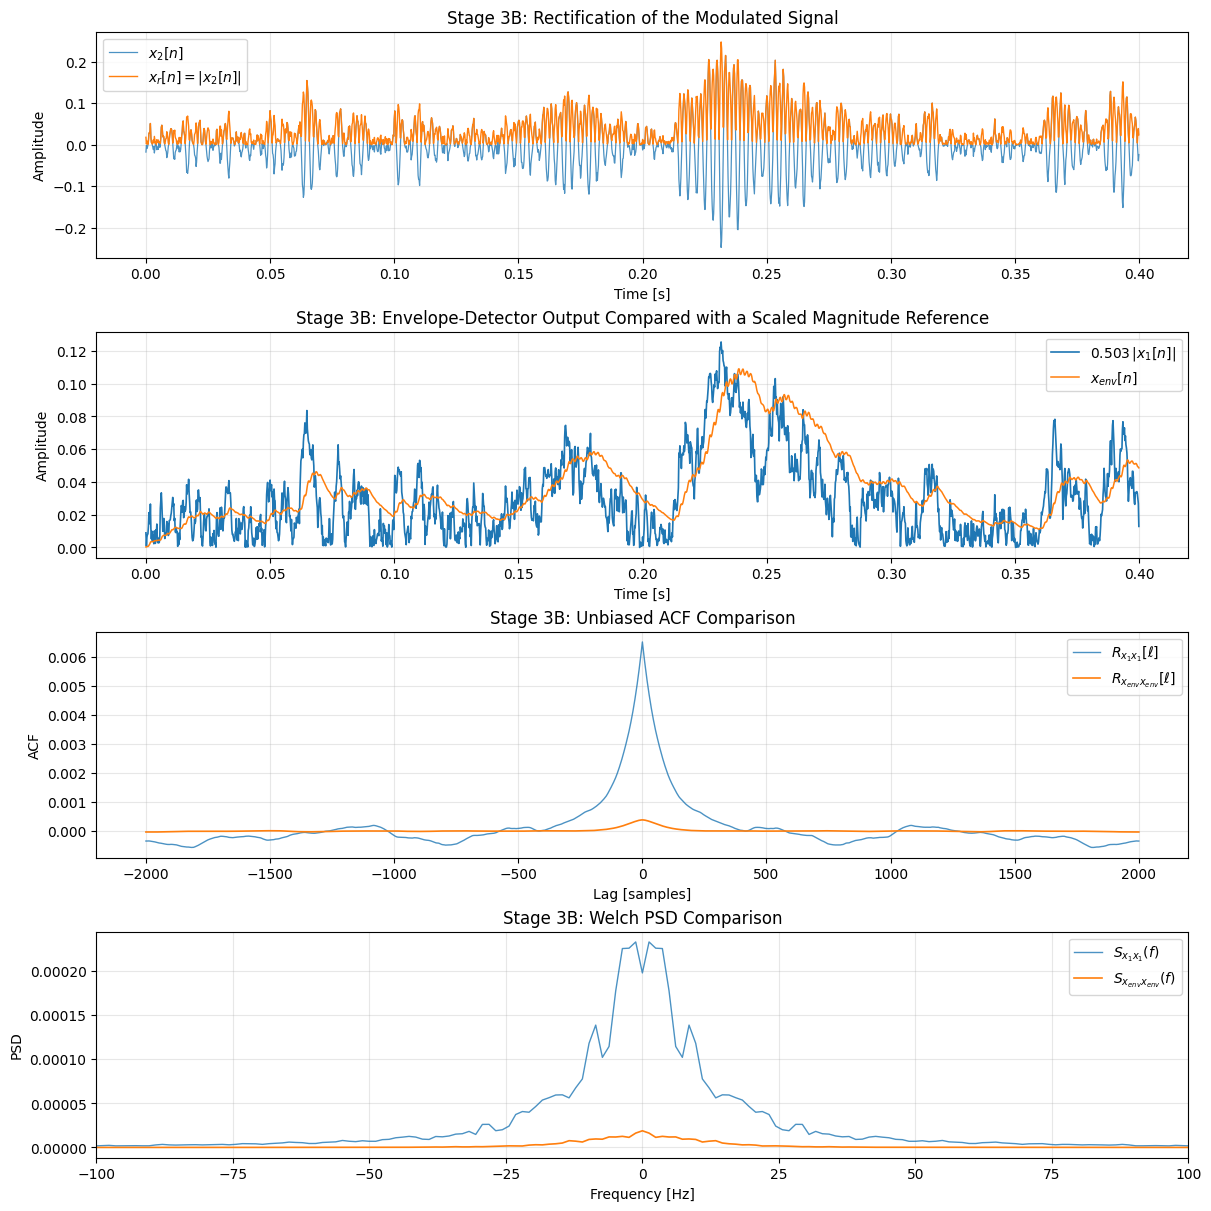

Envelope smoothing RC coefficient alpha_env = 0.981327
Sample mean of x_env[n]: +4.1267e-02
Sample variance of x_env[n]: 0.0004
Best-fit envelope scale relative to |x_1[n]|: 0.5030
Correlation between x_env[n] and scaled |x_1[n]|: 0.6484


In [26]:
# Stage 3B: envelope-detector comparison path
x_r = np.abs(x_2)
x_env, alpha_env = rc_lowpass(x_r, f_c=f_env, fs=f_s)

lags_env, acf_xenv = unbiased_acf(x_env, max_lag=max_lag)
freqs_xenv, psd_xenv = welch_psd(x_env, fs=f_s)

env_reference = np.abs(x_1)
env_fit_scale = np.dot(x_env, env_reference) / np.dot(env_reference, env_reference)
scaled_env_reference = env_fit_scale * env_reference
env_shape_corr = np.corrcoef(x_env, scaled_env_reference)[0, 1]

fig, axes = plt.subplots(4, 1, figsize=(12, 12), constrained_layout=True)

axes[0].plot(t[:time_window], x_2[:time_window], label=r"$x_2[n]$", linewidth=0.9, alpha=0.8)
axes[0].plot(t[:time_window], x_r[:time_window], label=r"$x_r[n] = |x_2[n]|$", linewidth=1.0)
axes[0].set_title("Stage 3B: Rectification of the Modulated Signal")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[:time_window], scaled_env_reference[:time_window], label=fr"${env_fit_scale:.3f}\,|x_1[n]|$", linewidth=1.2)
axes[1].plot(t[:time_window], x_env[:time_window], label=r"$x_{env}[n]$", linewidth=1.1)
axes[1].set_title("Stage 3B: Envelope-Detector Output Compared with a Scaled Magnitude Reference")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Amplitude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(lags_1, acf_x1, label=r"$R_{x_1x_1}[\ell]$", linewidth=1.0, alpha=0.8)
axes[2].plot(lags_env, acf_xenv, label=r"$R_{x_{env}x_{env}}[\ell]$", linewidth=1.2)
axes[2].set_title("Stage 3B: Unbiased ACF Comparison")
axes[2].set_xlabel("Lag [samples]")
axes[2].set_ylabel("ACF")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(freqs_x1, psd_x1, label=r"$S_{x_1x_1}(f)$", linewidth=1.0, alpha=0.8)
axes[3].plot(freqs_xenv, psd_xenv, label=r"$S_{x_{env}x_{env}}(f)$", linewidth=1.2)
axes[3].set_title("Stage 3B: Welch PSD Comparison")
axes[3].set_xlabel("Frequency [Hz]")
axes[3].set_ylabel("PSD")
axes[3].set_xlim(-100, 100)
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.show()

print(f"Envelope smoothing RC coefficient alpha_env = {alpha_env:.6f}")
print(f"Sample mean of x_env[n]: {np.mean(x_env):+.4e}")
print(f"Sample variance of x_env[n]: {np.var(x_env):.4f}")
print(f"Best-fit envelope scale relative to |x_1[n]|: {env_fit_scale:.4f}")
print(f"Correlation between x_env[n] and scaled |x_1[n]|: {env_shape_corr:.4f}")


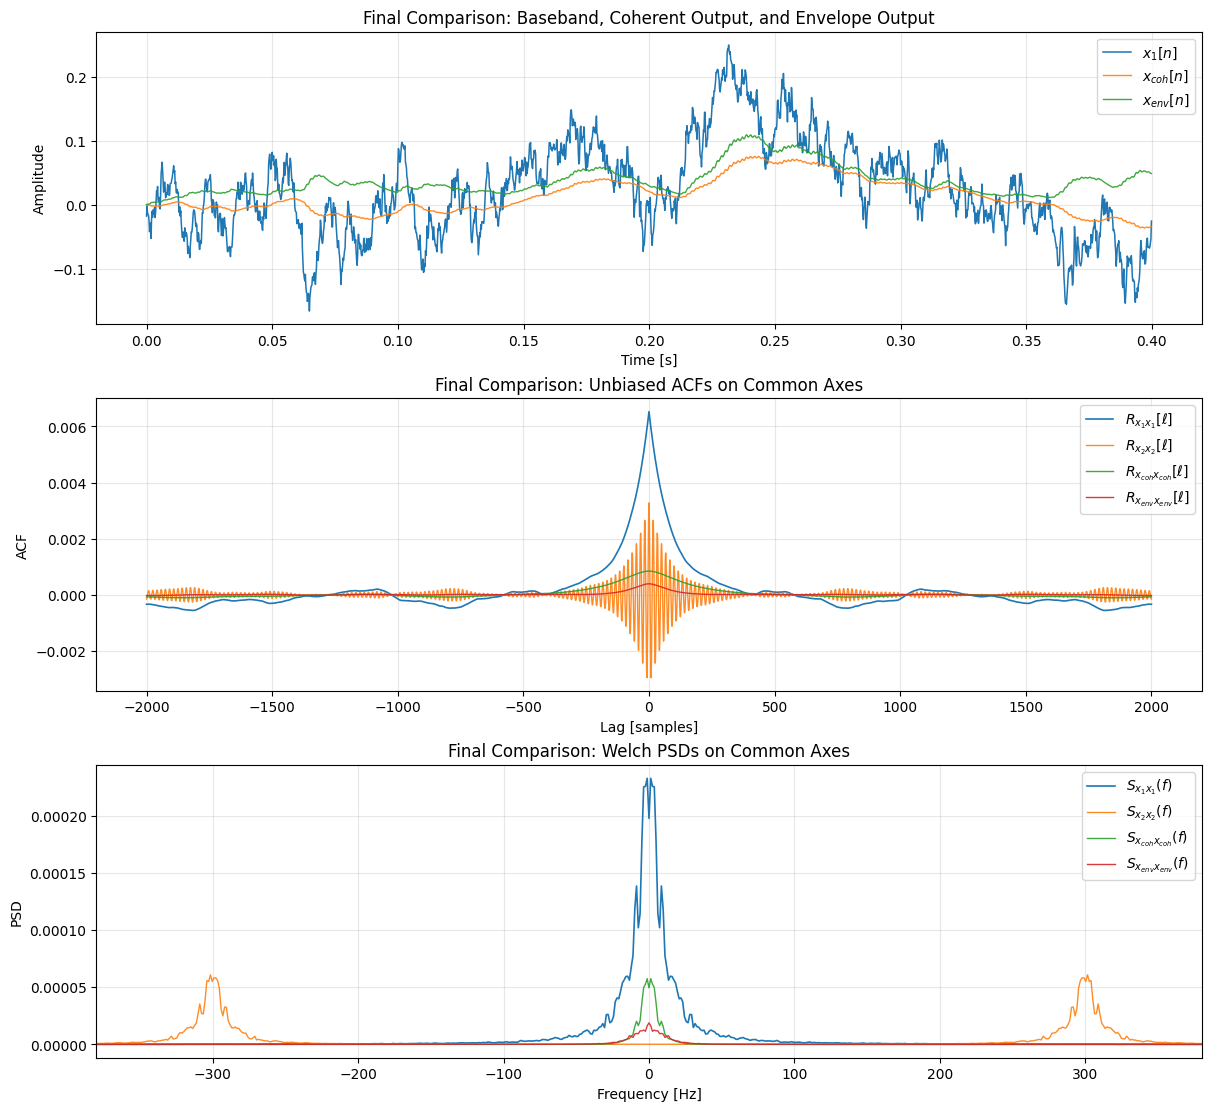

Summary metrics
Baseband variance          : 0.006529
Coherent-output variance   : 0.000847
Envelope-output variance   : 0.000394
Coherent/baseband var ratio: 0.129695
Envelope/baseband var ratio: 0.060372
Best-fit coherent scale    : 0.261992
Best-fit envelope scale    : 0.503039
Corr(x_coh, x_1)           : 0.724321
Corr(x_env, x_1)           : 0.097877
Corr(x_env, |x_1| ref.)    : 0.648393

Interpretation
- The coherent branch should return to baseband and stay closer to x_1[n] than the envelope branch does, even if the non-ideal RC filter changes the exact amplitude.
- The envelope branch can track slow magnitude variation, but it does not preserve the signed baseband process.
- The common-axis PSD comparison should show baseband recovery for the coherent receiver and a different low-frequency structure for the envelope detector.


In [27]:
# Final comparison and discussion summary
fig, axes = plt.subplots(3, 1, figsize=(12, 11), constrained_layout=True)

comparison_window = 2000
axes[0].plot(t[:comparison_window], x_1[:comparison_window], label=r"$x_1[n]$", linewidth=1.1)
axes[0].plot(t[:comparison_window], x_coh[:comparison_window], label=r"$x_{coh}[n]$", linewidth=1.0, alpha=0.9)
axes[0].plot(t[:comparison_window], x_env[:comparison_window], label=r"$x_{env}[n]$", linewidth=1.0, alpha=0.9)
axes[0].set_title("Final Comparison: Baseband, Coherent Output, and Envelope Output")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lags_1, acf_x1, label=r"$R_{x_1x_1}[\ell]$", linewidth=1.2)
axes[1].plot(lags_2, acf_x2, label=r"$R_{x_2x_2}[\ell]$", linewidth=1.0, alpha=0.9)
axes[1].plot(lags_coh, acf_xcoh, label=r"$R_{x_{coh}x_{coh}}[\ell]$", linewidth=1.0, alpha=0.9)
axes[1].plot(lags_env, acf_xenv, label=r"$R_{x_{env}x_{env}}[\ell]$", linewidth=1.0, alpha=0.9)
axes[1].set_title("Final Comparison: Unbiased ACFs on Common Axes")
axes[1].set_xlabel("Lag [samples]")
axes[1].set_ylabel("ACF")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(freqs_x1, psd_x1, label=r"$S_{x_1x_1}(f)$", linewidth=1.2)
axes[2].plot(freqs_x2, psd_x2, label=r"$S_{x_2x_2}(f)$", linewidth=1.0, alpha=0.9)
axes[2].plot(freqs_xcoh, psd_xcoh, label=r"$S_{x_{coh}x_{coh}}(f)$", linewidth=1.0, alpha=0.9)
axes[2].plot(freqs_xenv, psd_xenv, label=r"$S_{x_{env}x_{env}}(f)$", linewidth=1.0, alpha=0.9)
axes[2].set_title("Final Comparison: Welch PSDs on Common Axes")
axes[2].set_xlabel("Frequency [Hz]")
axes[2].set_ylabel("PSD")
axes[2].set_xlim(-(f_0 + 80.0), f_0 + 80.0)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.show()

baseband_power = np.var(x_1)
coh_power = np.var(x_coh)
env_power = np.var(x_env)
coh_shape_ratio = coh_power / baseband_power if baseband_power > 0 else np.nan
env_shape_ratio = env_power / baseband_power if baseband_power > 0 else np.nan

coh_norm_corr = np.corrcoef(x_coh - np.mean(x_coh), x_1 - np.mean(x_1))[0, 1]
env_signed_corr = np.corrcoef(x_env - np.mean(x_env), x_1 - np.mean(x_1))[0, 1]

print("Summary metrics")
print(f"Baseband variance          : {baseband_power:.6f}")
print(f"Coherent-output variance   : {coh_power:.6f}")
print(f"Envelope-output variance   : {env_power:.6f}")
print(f"Coherent/baseband var ratio: {coh_shape_ratio:.6f}")
print(f"Envelope/baseband var ratio: {env_shape_ratio:.6f}")
print(f"Best-fit coherent scale    : {coh_fit_scale:.6f}")
print(f"Best-fit envelope scale    : {env_fit_scale:.6f}")
print(f"Corr(x_coh, x_1)           : {coh_norm_corr:.6f}")
print(f"Corr(x_env, x_1)           : {env_signed_corr:.6f}")
print(f"Corr(x_env, |x_1| ref.)    : {env_shape_corr:.6f}")

print("\nInterpretation")
print("- The coherent branch should return to baseband and stay closer to x_1[n] than the envelope branch does, even if the non-ideal RC filter changes the exact amplitude.")
print("- The envelope branch can track slow magnitude variation, but it does not preserve the signed baseband process.")
print("- The common-axis PSD comparison should show baseband recovery for the coherent receiver and a different low-frequency structure for the envelope detector.")
